In [1]:
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import os
from scipy.ndimage import zoom

In [2]:
# Construct file list
file_list = []

for root, folder, files in os.walk("../data/foil_slice_processed"):
    for file_name in files:
        file_list.append(os.path.join(
            root, file_name
        ))
file_list = natsorted(file_list)
# Read data into memory
data_list = []
for i in range(len(file_list)):
    data_list.append(
        np.load(file_list[i])
    )
data = np.stack(data_list, axis=0)

In [3]:
data = np.nan_to_num(data, nan=0)

In [17]:
data[:, 0, :, :].flatten().min()

-2594.0443852982135

In [18]:
u_min, u_max = data[:, 0, :, :].flatten().min(), data[:, 0, :, :].flatten().max()
v_min, v_max = data[:, 1, :, :].flatten().min(), data[:, 1, :, :].flatten().max()
p_min, p_max = data[:, 2, :, :].flatten().min(), data[:, 2, :, :].flatten().max()

min_max = [
    [u_min, u_max],
    [v_min, v_max],
    [p_min, p_max]
]

min_max

# min_max = [
#     [u_min, u_max],
#     [v_min, v_max],
#     [p_min, p_max]
# ]
# [[-2594.0443852982135, 13496.993103354653],
#  [-8785.563892721984, 7011.130561473838],
#  [-61036889.876922235, 47903534.184199974]]

[[-2594.0443852982135, 13496.993103354653],
 [-8785.563892721984, 7011.130561473838],
 [-61036889.876922235, 47903534.184199974]]

In [40]:
print(mask[150:150+64, 150:150+128].shape)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

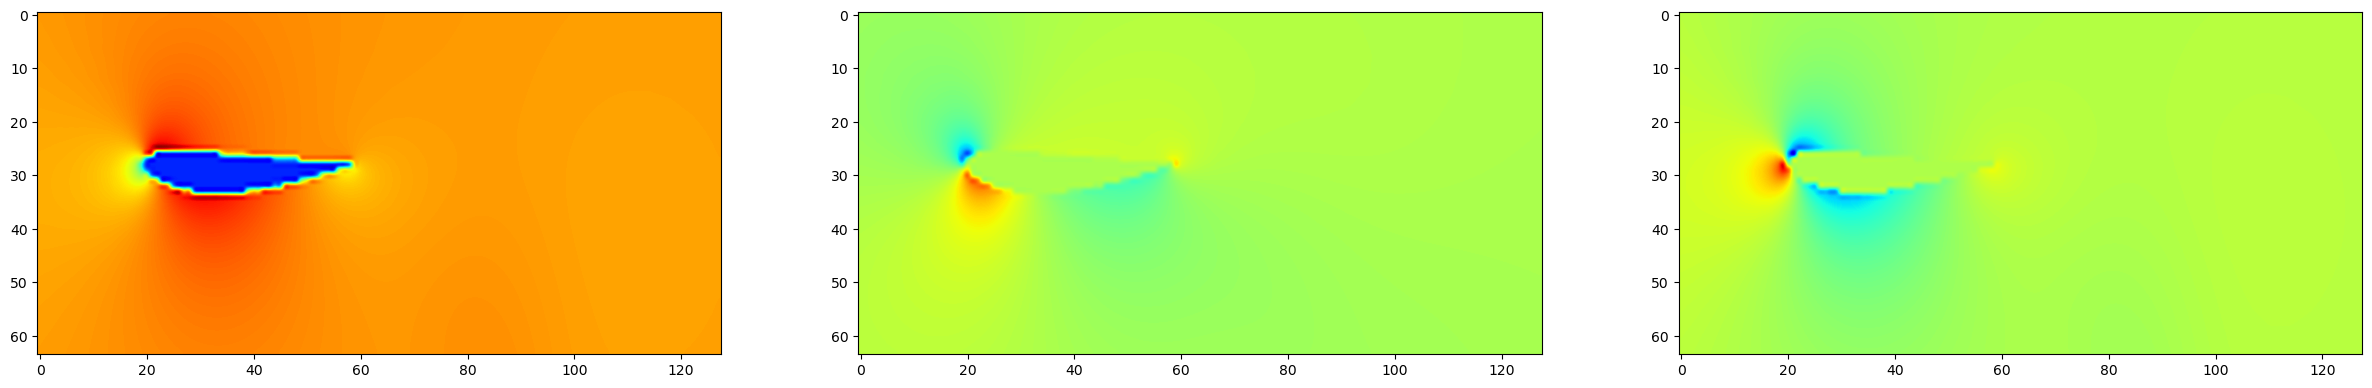

In [46]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, axs = plt.subplots(1, 3, figsize=(30, 10))

def plot_frame(frame):
    d = data[frame]
    d = zoom(d, (1, 0.4 , 0.4), order=1)
    for i in range(3):
        axs[i].clear()
        # axs[i].imshow(d[i], cmap="jet", vmin=min_max[i][0], vmax=min_max[i][1])
        axs[i].imshow(
            d[i][150:150+64, 150:150+128] * mask[150:150+64, 150:150+128], cmap="jet",
            vmin=min_max[i][0], vmax=min_max[i][1],
            interpolation="catrom"
        )

anim = FuncAnimation(fig, plot_frame, frames=2000, interval=10)
HTML(anim.to_html5_video())

In [29]:
from scipy.ndimage import zoom

In [30]:
d = data[1000, 0]

In [44]:
mask = (d != 0)
mask.shape

(410, 410)

In [31]:
d.shape

(1024, 1024)

In [32]:
d = zoom(d, (0.4 , 0.4), order=1)

In [33]:
v_min = d.min()
v_max = d.max()

In [34]:
v_min, v_max

(-163.2435710102574, 12010.370887681125)

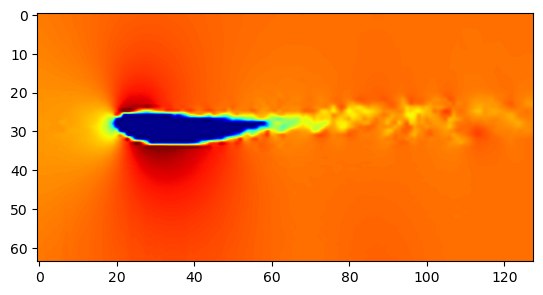

In [35]:
y_start = 150
x_start = 150
plt.imshow(
    d[x_start: x_start+64, y_start: y_start+128] * mask[150:150+64, 150:150+128],
    cmap="jet",
    interpolation="catrom"
    # vmin=v_min, vmax=v_max,
    )

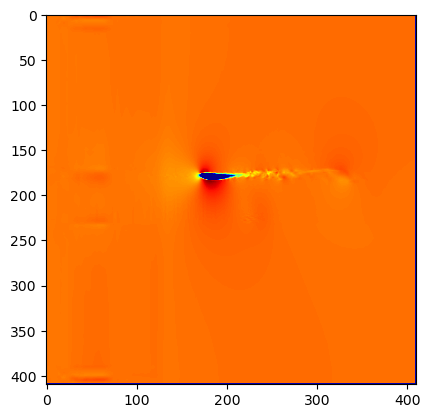

In [14]:
plt.imshow(d, cmap='jet', vmin=v_min, vmax=v_max)